# Titanic Survival Prediction - 
### A Logistic Regression Project

In [98]:
## Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [99]:
## Loading the Dataset
train = pd.read_csv("/Users/mac/Desktop/Desktop_Files/Projects/Titanic Survival Prediction/titanic_train.csv")

In [100]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


- Parch = parents and Children
- Sibsp = Siblings and Spouse

In [101]:
train.shape

(891, 12)

### Checking for Missing Values

In [102]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

<Axes: >

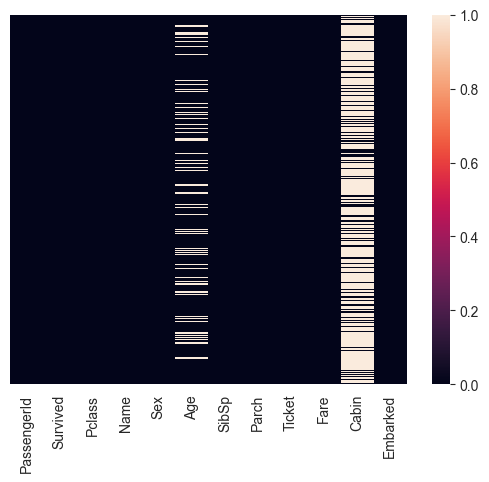

In [103]:
sns.heatmap(train.isnull(), yticklabels=False)

In [104]:
## Checking for Missing Values in percentage in each column
features_with_na = [features for features in train.columns if train[features].isnull().sum()>1]
features_with_na

['Age', 'Cabin', 'Embarked']

In [105]:
## Printing the %age of missing values in each column with missing values
for feature in features_with_na:
    print(feature, np.round(train[feature].isnull().mean()*100, 4), ' % missing values')

Age 19.8653  % missing values
Cabin 77.1044  % missing values
Embarked 0.2245  % missing values


- 20% of age data is missing
- 77% of Cabin data is missing

/var/folders/49/z4dsjwnj3bz30nknl9ffld4h0000gn/T/ipykernel_20617/3781976998.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=train, palette='mako')


<Axes: xlabel='Survived', ylabel='count'>

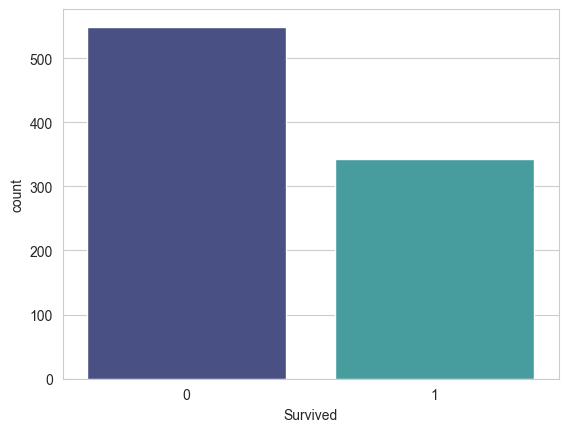

In [106]:
sns.set_style('whitegrid')
sns.countplot(x='Survived', data=train, palette='mako')

### Chekcing relation with the Sex of the Passenger, 
- If they have any relation with their survival rate

<Axes: xlabel='Survived', ylabel='count'>

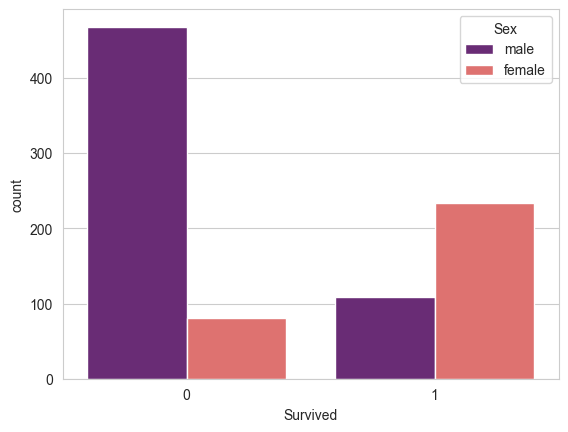

In [107]:
sns.set_style('whitegrid')
sns.countplot(x='Survived', hue='Sex', data=train, palette='magma')

### Findingd-> Females had higher survival rate
- among survived ones, Females survived more.
- Same happened for "Those Who didn't Survive" , here Females were minority.

### Checkin with the Pclass , {Passenger Class}
- If there is any relation 

<Axes: xlabel='Survived', ylabel='count'>

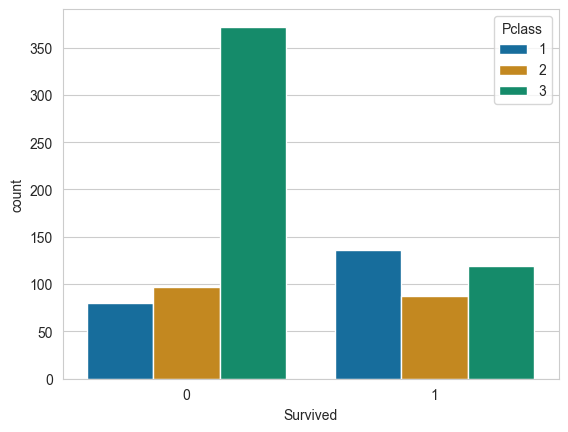

In [108]:
sns.set_style('whitegrid')
sns.countplot(x='Survived', hue='Pclass', data=train, palette='colorblind')

### Doin the same with the AGE column
- dropping na bcz it has a lot of missing values

/var/folders/49/z4dsjwnj3bz30nknl9ffld4h0000gn/T/ipykernel_20617/3914480385.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train['Age'].dropna(),kde=False, bins=40, color='darkgreen')


<Axes: xlabel='Age'>

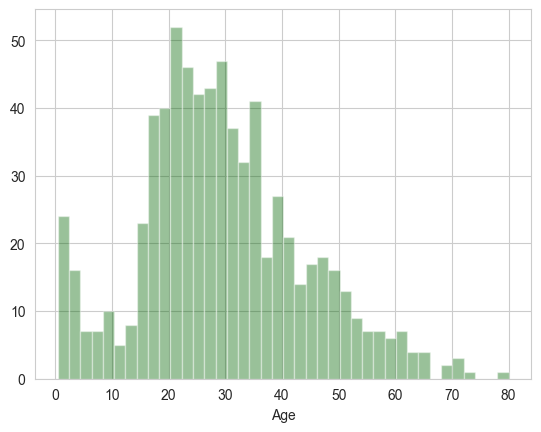

In [109]:
sns.distplot(train['Age'].dropna(),kde=False, bins=40, color='darkgreen')

### No. pf siblings the passenger had

/var/folders/49/z4dsjwnj3bz30nknl9ffld4h0000gn/T/ipykernel_20617/155987677.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='SibSp', data = train, palette='muted')


<Axes: xlabel='SibSp', ylabel='count'>

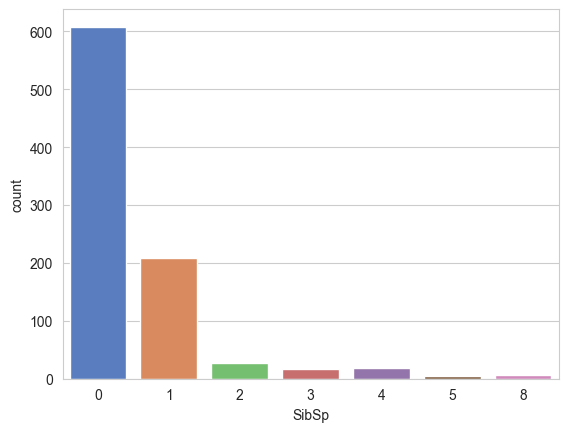

In [110]:
sns.countplot(x='SibSp', data = train, palette='muted')

- majority has no or 1 sibling and spouse

### Finding Train Fare Histogram , 

In [111]:
np.round(train['Fare'].mean(),2)

np.float64(32.2)

<Axes: >

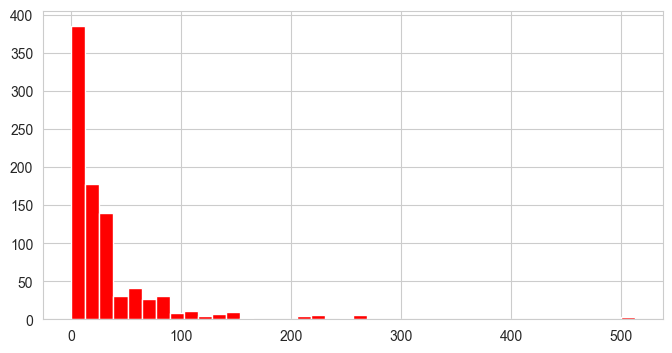

In [112]:
train['Fare'].hist(color='red',bins=40, figsize=(8,4))

## Data Cleaning ->
- Age and Cabin column to be handled (Filling with mean)
- Or any other techniques

##### Checking avg age by Passenger Class

/var/folders/49/z4dsjwnj3bz30nknl9ffld4h0000gn/T/ipykernel_20617/3581520545.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pclass', y='Age',data=train, palette='muted')


<Axes: xlabel='Pclass', ylabel='Age'>

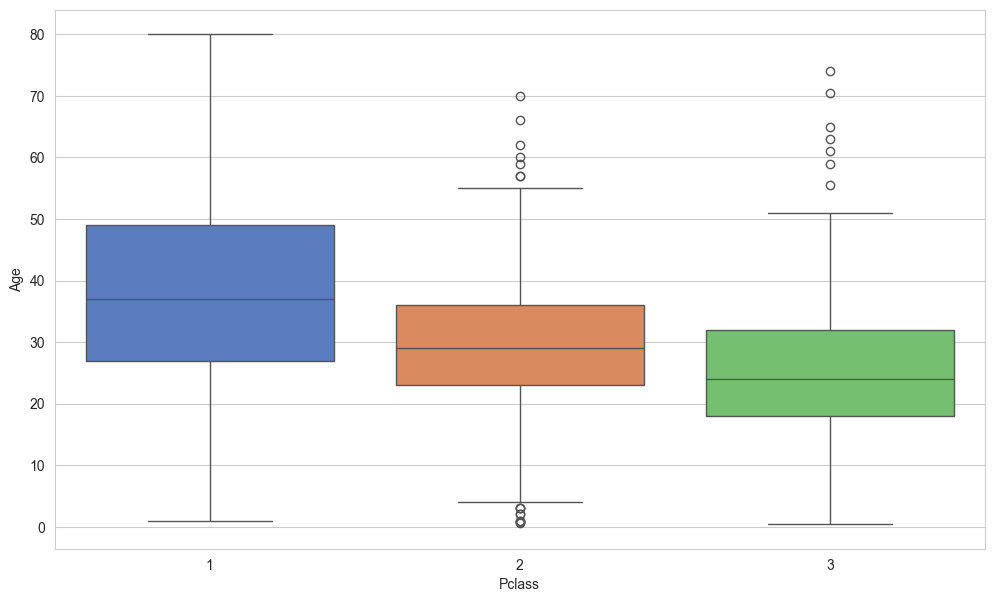

In [113]:
plt.figure(figsize=(12,7))
sns.boxplot(x='Pclass', y='Age',data=train, palette='muted')

### Findings->
- Passenger class 1 has Older Poeple 
- Than Other two classes Comparatively

- Pclass 1 has mean of 37
- Pclass 2 has mean of 29
- Pclass 3 has mean of 24

#### Fillin the nan values with the avg/mean but accrodin to the Pclass

In [114]:
def impute_age(cols):
    Age = cols[0]
    Pclass = cols[1]

    if pd.isnull(Age):

        if Pclass ==1:
            return 37
        
        elif Pclass ==2:
            return 29
        
        elif Pclass == 3:
            return 24
    
    else:
        return Age


In [115]:
## Using this function to impute the values now->
train['Age'] = train[['Age', 'Pclass']].apply(impute_age, axis=1)

/var/folders/49/z4dsjwnj3bz30nknl9ffld4h0000gn/T/ipykernel_20617/2794348225.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Age = cols[0]
/var/folders/49/z4dsjwnj3bz30nknl9ffld4h0000gn/T/ipykernel_20617/2794348225.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Pclass = cols[1]


Checkin the imputation

<Axes: >

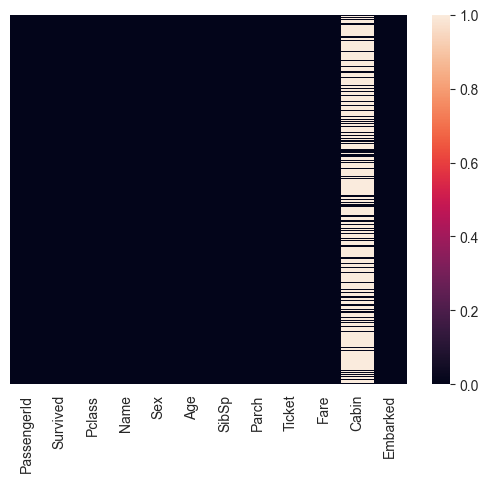

In [116]:
sns.heatmap(train.isnull(), yticklabels=False)

Age Column has been handled for the missin values

### Handling Cabin null Values -> 77% NaN

In [117]:
for feature in features_with_na:
    print(feature, np.round(train[feature].isnull().mean(),4))

Age 0.0
Cabin 0.771
Embarked 0.0022


The Cabin column requires Feature Enineerin to handle its NaN values, we are droppin it for now

In [118]:
train.drop('Cabin', axis=1, inplace=True)

In [119]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
